In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
file_dir_1 = r"D:\研三\大山1-毕业论文\代码\v41_data\modulus_data_2.npy"
file_dir_2 = r"D:\研三\大山1-毕业论文\代码\v41_data\pressure_data_3.npy"
data_mod = np.load(file_dir_1)
data_pre = np.load(file_dir_2)

In [3]:
#归一化函数
def normarlized(input_images):
    min_val = np.min(input_images)
    max_val = np.max(input_images)
    # 归一化操作，将数据范围从 [min_val, max_val] 映射到 [0, 1]
    normalized_images = (input_images - min_val) / (max_val - min_val)
    return normalized_images

data_pre = normarlized(data_pre)
data_mod = normarlized(data_mod)

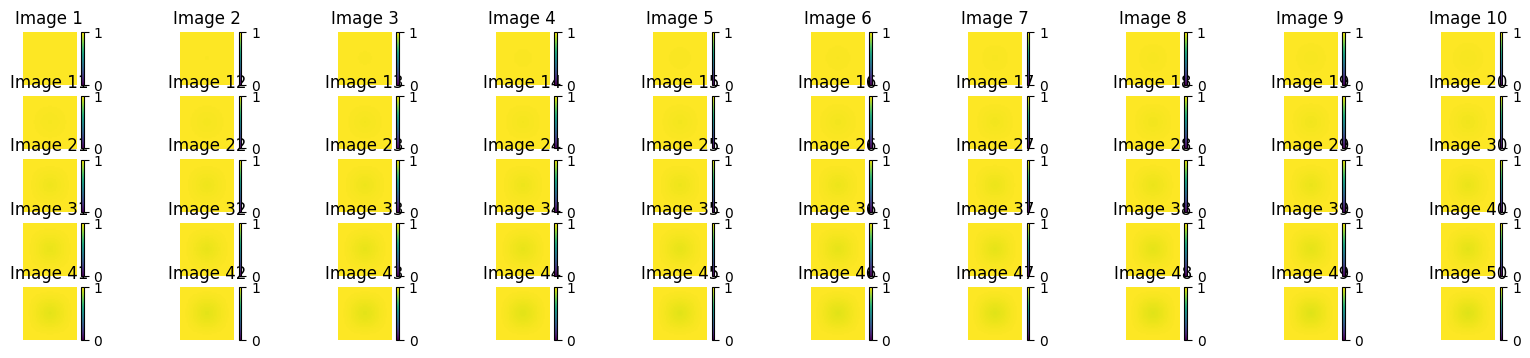

In [4]:
#样本绘制函数
def sample_index(input_images):
    fig, axes = plt.subplots(5, 10, figsize=(20, 4))  # 设置图像大小为20x4，方便查看
    axes = axes.flatten()
    fig.subplots_adjust(wspace=0.2)  # 调整每个子图之间的间距
    # 打印每张图片的最大值及其位置，并显示图片
    for idx in range(50):
        image = input_images[idx]  # 获取第idx张图片
        im = axes[idx].imshow(image, cmap='viridis', vmin=0, vmax=1)  # 使用 'viridis' 色图，设置颜色条范围为 [0, 1]
        axes[idx].set_title(f"Image {idx + 1}")
        axes[idx].axis('off')  # 关闭坐标轴
        # 添加颜色条
        plt.colorbar(im, ax=axes[idx], fraction=0.02, pad=0.04)  # 添加颜色条，确保颜色条在 [0, 1] 范围内

    # 显示所有图片
    plt.show()

sample_index(data_pre)

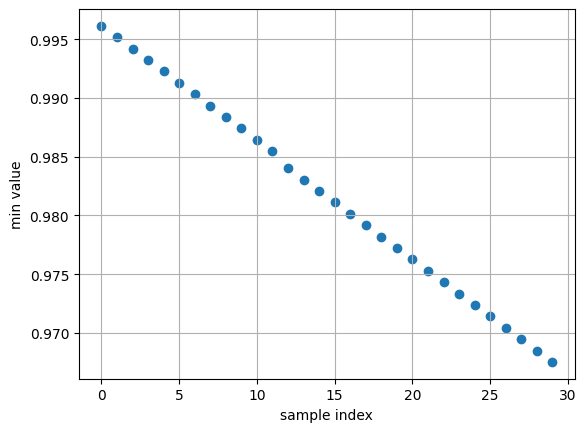

In [5]:
mins = [data_pre[i].min() for i in range(30)]
import matplotlib.pyplot as plt
plt.scatter(range(30), mins)
plt.xlabel("sample index")
plt.ylabel("min value")
plt.grid(True)
plt.show()

In [22]:
for i in [20, 21, 22, 23, 24, 25]:
    print("{:.32f}".format(data_pre[i].min()))

0.89397590361445788964545045018895
0.89156626506024094780400446325075
0.98795180722891562385967745285598
0.89156626506024094780400446325075
0.88915662650602411698486093882821
0.88915662650602411698486093882821


In [16]:
x1 = data_mod[401][20,:]
x2 = data_mod[601][20,:]
x3 = data_mod[801][20,:]
y1 = data_pre[0][20,:]
y2 = data_pre[329][20,:]

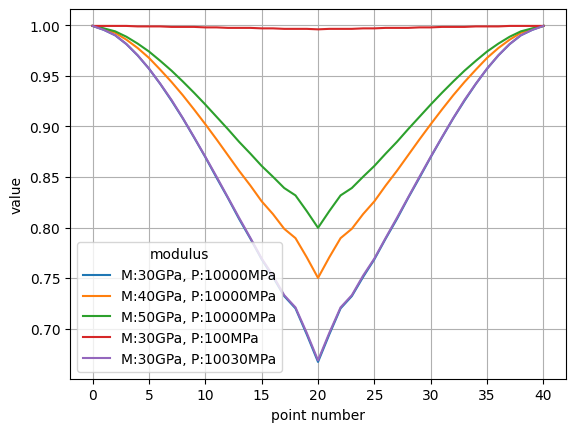

In [17]:
plt.plot(x1, label = "M:30GPa, P:10000MPa")
plt.plot(x2, label = "M:40GPa, P:10000MPa")
plt.plot(x3, label = "M:50GPa, P:10000MPa")
plt.plot(y1, label = "M:30GPa, P:100MPa")
plt.plot(y2, label = "M:30GPa, P:10030MPa")
plt.xlabel("point number")
plt.ylabel("value")
plt.grid(True)
plt.legend(title="modulus", loc="best")  
plt.show()



In [ ]:
file_dir = r"D:\研三\大山1-毕业论文\代码\v41_data\pressure_data.npy"
data_pre= np.load(file_dir)


In [ ]:
y1 = data_pre[91][20,:]
y2 = data_pre[92][20,:]
plt.plot(y1, label = "pressure:1000MPa")
plt.plot(y2, label = "modulus:50GPa")
plt.xlabel("point number")
plt.ylabel("value")
plt.grid(True)
plt.legend(title="modulus", loc="best")  
plt.show()

In [ ]:
data_pre = data_pre[2:]


In [ ]:
import torch
import torchvision.utils as vutils
from Network import VAE_41
model = VAE_41()   # 这里应该是你的模型定义
model.load_state_dict(torch.load('./weight/size41_0130test1.pth'))  # 加载预训练的权重

In [ ]:
data_input = normarlized(data_pre)

In [ ]:
sample_index(data_input)

In [ ]:
data_in = torch.from_numpy(data_in).float().unsqueeze(1)

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# =========================
# 0) 你需要准备的变量：
# - data_input: (1000,1,41,41) numpy 或 torch
# - model_path: 权重路径
# - load_model(model_path, device): 你已有的加载函数
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) 取前500条（保持原始顺序）
x500 = data_in[:500]  # (500,1,41,41)

# 2) 转成 torch.Tensor
if isinstance(x500, np.ndarray):
    x500 = torch.from_numpy(x500)
x500 = x500.float()

# 3) 只加载一次模型
model.eval()
model.to(device)
# 4) 批量推理拿到 z: (500,8)
bs = 128
Z_list = []
MU_list = []

with torch.no_grad():
    for i in range(0, x500.shape[0], bs):
        xb = x500[i:i+bs].to(device)  # (B,1,41,41)
        # 编码器输出
        mu, logvar = model.encode(xb)
        mu = mu.view(mu.shape[0], -1)   # 保证 (B,8)
        MU_list.append(mu.cpu())
        # 重参数化得到潜在向量
        #z = model.reparameterize(mu, logvar)
        # 有些实现会输出 (B,8,1,1)；这里统一拉平成 (B,8)
        #z = z.view(z.shape[0], -1)
        #Z_list.append(z.detach().cpu())
MU = torch.cat(MU_list, dim=0).numpy()
#Z = torch.cat(Z_list, dim=0).numpy()  # (500,8)
#print("Z shape =", Z.shape)
idx = np.arange(MU.shape[0])  # 0~499，作为颜色
plt.figure(figsize=(7, 6))
sc = plt.scatter(MU[:, 1], MU[:, 5], c=idx, cmap="Blues", s=30)  # Blues: 越大越深
plt.colorbar(sc, label="Sample index")
plt.xlabel("Latent dim 1 (mu)")
plt.ylabel("Latent dim 2 (mu)")
plt.title("Dim1 vs Dim2 (color darker as index increases)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5) 画 8 个维度的趋势（8个子图）
x = np.arange(MU.shape[0])  # 0~499

plt.figure(figsize=(12, 10))
for k in range(16):
    ax = plt.subplot(8, 2, k + 1)
    ax.plot(x, MU[:, k])
    ax.set_title(f"Latent dim {k+1}")
    ax.set_xlabel("Sample index (0~499)")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
'''
# 6)（可选）再给你一个 500×8 的热力图，一眼看整体趋势
plt.figure(figsize=(10, 5))
plt.imshow(Z, aspect='auto')
plt.colorbar(label="Value")
plt.xlabel("Latent dimension (0~7)")
plt.ylabel("Sample index (0~499)")
plt.title("Latent vectors heatmap (500x8)")
plt.tight_layout()
plt.show()
'''


In [ ]:
sample_idx = 500 # 选择一个测试样本
x = data_in[sample_idx]
x = x.unsqueeze(0).to(device)
# 1. 获取基准分布
with torch.no_grad():
    mu, logvar = model.encode(x)
    sigma = torch.exp(0.5 * logvar)
    steps = torch.tensor([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0], device=mu.device)  

# 2. 遍历前 5 个维度 (假设总维度较多)
all_images = []
min_list = []
for d in range(16):
    # 针对每一个维度，生成从 -3 到 3 的 8 张图
    temp_mu = mu.repeat(7, 1)
    temp_mu[:, d] = steps #大扰动
    #temp_mu[:, d] = mu[:, d] + steps * sigma[:, d] #小扰动

    with torch.no_grad():
        #print(temp_mu.shape)
        decoded = model.decode(temp_mu)
        mins = decoded.view(decoded.size(0), -1).min(dim=1).values
        all_images.append(decoded)
    min_list = mins.detach().cpu().tolist()

In [ ]:
min_values_matrix = []  # 你可以换个名字，比如 row_values_matrix
row_values_matrix = []

row_idx = 20  # 第21行（0-based）

for dim_idx in range(len(all_images)):
    dim_images = all_images[dim_idx]          # [7, 1, 41, 41]
    rows = dim_images[:, 0, row_idx, :]       # [7, 41]  取7张图的第21行

    row_values_matrix.append(rows.detach().cpu().tolist())


In [ ]:
# 画折线图 
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(min_list)+1), min_list, marker='o')
plt.xlabel("latent index (1~10)")
plt.ylabel("min value of decoded image")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# row_values_matrix: list，长度16；每个元素长度7；每条长度41
data = np.array(row_values_matrix)  # shape: (16, 7, 41)

x = np.arange(data.shape[2])  # 0~40（你也可以改成 1~41：np.arange(1, data.shape[2]+1)）

fig, axes = plt.subplots(16, 1, figsize=(16, 48), sharex=True, sharey=True)
axes = axes.ravel()
tag = ["-3σ", "-2σ", "-1σ", "0", "+1σ", "+2σ", "+3σ"]
for dim_idx in range(data.shape[0]):
    ax = axes[dim_idx]
    for i in range(data.shape[1]):  # 7条线
        ax.plot(x, data[dim_idx, i], label=tag[i])
    ax.set_title(f"dim {dim_idx}")
    ax.grid(True, alpha=0.3)

# 删除多余子图（以防 data 不是16）
for k in range(data.shape[0], len(axes)):
    fig.delaxes(axes[k])

# ✅整张图共用一个图例（避免每个子图都挤一个legend）
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 1), title="images")

fig.supxlabel("point index")
fig.supylabel("value")
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# 设置画布大小
plt.figure(figsize=(12, 7))

# 遍历每一行数据（每一个维度）
for i in range(len(df)):
    # df.iloc[i] 对应一个维度在 7 个 sigma 下的最小值
    plt.plot(column_names, df.iloc[i], marker='o', label=df.index[i] if i < 10 else "")

# 优化图表
plt.title("Min Value Trend across Latent Dimensions (-3σ to +3σ)", fontsize=14)
plt.xlabel("Perturbation Range", fontsize=12)
plt.ylabel("Matrix Min Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# 如果维度太多，图例会很乱，这里只显示前10个
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Dimensions")
plt.tight_layout()

plt.show()

In [ ]:
encoder = model.encode
decoder = model.decode

x1 = data_in[500]
x2 = data_in[550]
x1 = x1.unsqueeze(0).to(device)
x2 = x2.unsqueeze(0).to(device)

z1, _ = encoder(x1)  # 编码器得到潜在空间中的 z1
z2, _ = encoder(x2)  # 假设我们也可以从另一张图片获得 z2

lambdas = torch.linspace(0, 1, 10, device=z1.device, dtype=z1.dtype)
vector = []
for d in range(16):
    z_all = z1.repeat(10, 1)
    z_all[:, d] = (1 - lambdas) * z1[0, d] + lambdas * z2[0, d]
    vector.append(z_all)

# 使用解码器生成对应的图像
# all_images = []
# generated_images = []
# for z in range(16):
#     z = z.unsqueeze(0)  # 增加 batch 维度
#     with torch.no_grad():
#         generated_image = decoder(z)  # 解码器生成图像
#     generated_images.append(generated_image.squeeze(0).cpu())

# 可视化生成的图像
# fig, axes = plt.subplots(1, len(generated_images), figsize=(15, 5))
# for i, image in enumerate(generated_images):
#     axes[i].imshow(image.permute(1, 2, 0))  # 转换为 HWC 格式
#     axes[i].axis('off')
# plt.show()



In [ ]:
import torch
import matplotlib.pyplot as plt

# 假设 z_all: torch.Tensor, shape = (10, 16)
# 假设 decoder: 你的解码器（或 VAE 的 decode 函数）

model.eval()
with torch.no_grad():
    # --- ① 解码：得到10张图 ---
    # ✅按你的模型选择下面其中一种：
    x_rec = decoder(vector[0])          # 常见：decoder直接接收 (B, latent_dim)
    # x_rec = model.decode(z_all)   # 如果你的VAE是 model.decode(...)
    
    # --- ② 求每张图的最小值 ---
    # 兼容输出形状：(10,1,41,41) 或 (10,41,41) 或 (10, N)
    mins = x_rec.view(x_rec.size(0), -1).min(dim=1).values  # shape: (10,)

min_list = mins.detach().cpu().tolist()

# --- ③ 画折线图 ---
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(min_list)+1), min_list, marker='o')
plt.xlabel("latent index (1~10)")
plt.ylabel("min value of decoded image")
plt.grid(True)
plt.tight_layout()
plt.show()

print("min_list =", min_list)


In [ ]:
model.eval()
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.ravel()
for dim_idx in range(16):
    ax = axes[dim_idx]
    
    with torch.no_grad():
        x_rec = decoder(vector[dim_idx])          # 常见：decoder直接接收 (B, latent_dim)
        mins = x_rec.view(x_rec.size(0), -1).min(dim=1).values  # shape: (10,)
    
    min_list = mins.detach().cpu().tolist()

    ax.plot(range(1, len(min_list)+1), min_list, marker='o')
    ax.set_title(f"dim {dim_idx}")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 1), title="images")

fig.supxlabel("chazhijiange")
fig.supylabel("min_value")
plt.tight_layout()
plt.show()

In [ ]:
z_all = z1.repeat(10, 1)
lambdas = torch.linspace(0, 1, 10, device=z1.device, dtype=z1.dtype)  # (10,)

   




In [ ]:
min_list = []
for i in range(len(generated_images)):
    prev_image = generated_images[i]
    mins = torch.min(prev_image)
    min_list.append(mins)
    

In [ ]:

# 可视化 L2 距离变化
plt.plot(min_list, marker='o')
plt.title("L2 Distance between consecutive generated samples")
plt.xlabel("Lambda (Interpolation Parameter)")
plt.ylabel("L2 Distance")
plt.grid(True)
plt.show()